# Seventeen players, or one player seventeen times?

Every fit in this project has been **per player and independent**. Notebook 21
fitted each professional separately, notebook 24 did it again for two more
families, notebook 25 for a third, and nothing any player's darts said was ever
allowed to inform anyone else's estimate.

That is the right default -- it is the only way to *find out* that players differ
-- but it is not obviously the best estimator. The alternative says players are
drawn from a population:

$$\hat\theta_p \sim N(\theta_p,\ s_p^2), \qquad \theta_p \sim N(\mu,\ \tau^2)$$

and estimates $\mu$ and $\tau$ alongside the players. $\tau$ is the interesting
one: how much players differ *after* subtracting the noise in measuring them. At
$\tau = 0$ everyone is the same and the best estimate for anybody is the grand
mean; at $\tau \to \infty$ nothing is shared. In between, each player's estimate
is pulled toward the population by an amount set by how badly they were measured.

Notebook 25 is why this is worth asking here rather than in the abstract. A
player's lean has a split-half reliability of 0.45, and a parameter that badly
measured is exactly where partial pooling is supposed to earn its keep.

Three estimators, one held-out comparison: **no pooling**, **partial pooling**,
**complete pooling**. The last one is not a straw man -- it is what you get by
treating "a professional" as a single throw model, which is what the rest of the
project's ability bands do.

In [1]:
import os
import sys
module_path = os.path.abspath(os.path.join('..', '..'))
if module_path not in sys.path:
    sys.path.append(module_path)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.25,
    'grid.linewidth': 0.6, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 11, 'font.size': 9, 'legend.frameon': False,
})

from darts.hierarchical import (heterogeneity, random_effects, random_effects_mv,
                                shrink)
from darts.throw_families import FAMILIES, FamilyVisitModel, RadialBedGrid

PARAMS = ['log_scale', 'bias_x', 'log_nu_minus_2', 'e1', 'e2',
          'logit_s_hit', 'logit_s_miss']
RES = os.path.join(module_path, 'results', 'heterogeneity')
MODEL = FamilyVisitModel(FAMILIES['tilted-t'], RadialBedGrid(512))


def load(path):
    df = pd.read_csv(os.path.join(path, 'players.csv'))
    z = np.load(os.path.join(path, 'visits.npz'), allow_pickle=True)
    theta = np.stack([z[f'{i}_theta'] for i in range(len(df))])
    covs = np.stack([z[f'{i}_cov'] for i in range(len(df))])
    return df, z, theta, covs


FITS, Z, THETA, COVS = load(RES)
OK = np.array([np.isfinite(c).all() for c in COVS])
ll = lambda th, i: MODEL.log_likelihood(th, Z[f'{i}_b_te'], Z[f'{i}_h_te'])
BASE = np.array([ll(THETA[i], i) for i in range(len(FITS))])
N = FITS.n_test.values
print(f'{len(FITS)} players, {OK.sum()} with a full covariance, '
      f'{N.sum():,} held-out visits')

17 players, 12 with a full covariance, 5,469 held-out visits


## 1 · Before pooling anything: do they differ?

If $I^2$ is near zero the players are indistinguishable, the shrinkage will be
total, and the "hierarchical model" is complete pooling wearing a hat. So this is
the question to ask first, parameter by parameter.

One number to carry into reading it. The tests for `darts.hierarchical` measure
the power of this exact test at this exact sample size: seventeen players give
**about 62% power against a moderate $\tau = 0.3$**, and hold the nominal 5% size
under the null. So a null result here means "no large differences", not "no
differences".

In [2]:
rows = []
for j, name in enumerate(PARAMS):
    se = FITS['se_' + name].values
    m = np.isfinite(se)
    h = heterogeneity(THETA[m, j], se[m])
    r = random_effects(THETA[m, j], se[m])
    s = shrink(THETA[m, j], se[m], r['mu'], r['tau'])
    rows.append(dict(parameter=name, n=int(m.sum()), mu=r['mu'], tau=r['tau'],
                     I2=h['I2'], Q_p=h['p'], mean_shrinkage=1 - s['weight'].mean()))
het = pd.DataFrame(rows)
print('how much players differ, parameter by parameter:')
print(het.round(3).to_string(index=False))
print('\nplayers differ significantly on %d of %d parameters.'
      % ((het.Q_p < 0.05).sum(), len(het)))

how much players differ, parameter by parameter:
     parameter  n     mu   tau    I2   Q_p  mean_shrinkage
     log_scale 16  1.662 0.077 0.526 0.007           0.533
        bias_x 16 -1.292 2.231 0.841 0.000           0.150
log_nu_minus_2 12 -0.145 0.732 0.601 0.004           0.422
            e1 16  0.039 0.186 0.806 0.000           0.177
            e2 16 -0.011 0.091 0.355 0.079           0.664
   logit_s_hit 16 -2.950 0.685 0.828 0.000           0.216
  logit_s_miss 16 -0.934 0.556 0.954 0.000           0.047

players differ significantly on 6 of 7 parameters.


They differ, on six of the seven.

$I^2$ runs from 0.53 to 0.95 -- most of the observed spread between players is
real, not measurement noise. The exception is $e_2$, the lean, at $I^2 = 0.36$ and
$p = 0.079$: notebook 25 found the same thing and it fails to replicate on a
second split, so it belongs in the "no large differences" box rather than the
"they are the same" one.

Note which parameter gets shrunk hardest. It is $e_2$, at 0.66 -- the one with
the least evidence of real variation. That is the estimator doing exactly what it
is supposed to: pull hardest where the differences look most like noise. The
question is whether pulling helps.

## 2 · The comparison

Each player's parameters are fitted on their training legs; the shrinkage uses
only those; every estimator is scored on the same held-out legs.

In [3]:
def coordinatewise(df, theta):
    out = theta.copy()
    for j, name in enumerate(PARAMS):
        se = df['se_' + name].values
        m = np.isfinite(se)
        if m.sum() < 8:
            continue
        r = random_effects(theta[m, j], se[m])
        out[m, j] = shrink(theta[m, j], se[m], r['mu'], r['tau'])['posterior_mean']
    return out


COORD = coordinatewise(FITS, THETA)
POOLED = np.tile(Z['pooled_theta'], (len(FITS), 1))
scores = {}
for label, th in (('no pooling', THETA), ('partial pooling', COORD),
                  ('complete pooling', POOLED)):
    tot = sum(ll(th[i], i) for i in range(len(FITS)))
    scores[label] = tot
    print(f'{label:<20} held-out logL {tot:10.1f}   per visit {tot / N.sum():.4f}'
          f'   {tot - BASE.sum():+8.1f} vs no pooling')

no pooling           held-out logL   -22473.5   per visit -4.1093       -0.0 vs no pooling


partial pooling      held-out logL   -22513.7   per visit -4.1166      -40.2 vs no pooling


complete pooling     held-out logL   -22838.1   per visit -4.1759     -364.5 vs no pooling


**No pooling wins.** Partial pooling is 40 log units behind it, complete pooling
365 behind.

The second of those is the reassuring one and is worth saying first: treating all
seventeen professionals as one throw model costs **0.067 a visit**, which is a
tenth of the entire Gaussian-to-Student-t improvement notebook 21 measured. Real
players are not interchangeable, and any result that treats "a professional" as a
single parameter set is paying for it.

The first is the surprise. Shrinkage is supposed to help, and here it hurts.

In [4]:
print('shrinking one parameter at a time, to see where the loss comes from:')
for j, name in enumerate(PARAMS):
    se = FITS['se_' + name].values
    m = np.isfinite(se)
    r = random_effects(THETA[m, j], se[m])
    s = shrink(THETA[m, j], se[m], r['mu'], r['tau'])
    th = THETA.copy()
    th[m, j] = s['posterior_mean']
    d = np.array([ll(th[i], i) for i in range(len(FITS))]) - BASE
    print(f'   {name:<16} tau {r["tau"]:.3f}  shrunk {1 - s["weight"].mean():.2f}'
          f'  ->  {d.sum():+7.1f} log units')

d = np.array([ll(COORD[i], i) for i in range(len(FITS))]) - BASE
order = np.argsort(FITS.n_train.values)
print('\nand by how much data the player has:')
for lab, idx in (('smallest 6', order[:6]), ('middle 5', order[6:11]),
                 ('largest 6', order[11:])):
    print(f'   {lab:<12} n_train {FITS.n_train.values[idx].min():4d}-'
          f'{FITS.n_train.values[idx].max():4d}   {d[idx].sum():+7.1f} log units '
          f'({d[idx].sum() / N[idx].sum():+.4f} a visit)')

shrinking one parameter at a time, to see where the loss comes from:


   log_scale        tau 0.077  shrunk 0.53  ->    -32.8 log units


   bias_x           tau 2.231  shrunk 0.15  ->     +0.6 log units


   log_nu_minus_2   tau 0.732  shrunk 0.42  ->     -2.8 log units


   e1               tau 0.186  shrunk 0.18  ->     -1.4 log units


   e2               tau 0.091  shrunk 0.66  ->     -6.9 log units


   logit_s_hit      tau 0.685  shrunk 0.22  ->     -5.8 log units


   logit_s_miss     tau 0.556  shrunk 0.05  ->     -0.6 log units



and by how much data the player has:
   smallest 6   n_train  204- 263     -30.6 log units (-0.0215 a visit)
   middle 5     n_train  264- 307      +2.6 log units (+0.0018 a visit)
   largest 6    n_train  338- 650     -12.2 log units (-0.0046 a visit)


Two things in that, and the second is the diagnostic.

Almost all the damage is **one parameter**: the core scale, at $-32.8$ of the
$-40$ log units. It is the most precisely measured parameter of the seven and it
is shrunk the hardest of all except $e_2$ -- 53%. A small $\tau$ next to small
$s_p$ still means the players are genuinely apart; shrinking them together
discards real signal.

And it hurts **most on the players with the least data** -- $-0.0215$ a visit for
the smallest six against $-0.0046$ for the largest six. That is backwards. The
entire point of shrinkage is that badly measured units benefit most, and here they
suffer most. Something is wrong with the estimator, not merely unhelpful.

## 3 · The diagnosis, and the fix that does not fix it

Shrinking each coordinate toward its own mean quietly assumes the parameters are
independent. Across these players they are conspicuously not.

In [5]:
C = np.corrcoef(THETA.T)
print('correlation of the per-player estimates:')
print(pd.DataFrame(np.round(C, 2), index=PARAMS,
                   columns=[p[:9] for p in PARAMS]).to_string())
print(f'\nthe core-scale / nu ridge notebook 21 found at +0.62:  '
      f'r = {C[0, 2]:+.3f}')
print(f'core scale against elongation:                        r = {C[0, 3]:+.3f}')
print('\nso pulling each coordinate toward its own average drags the whole vector')
print('off the ridge the players actually lie on -- to a place no player is.')

correlation of the per-player estimates:
                log_scale  bias_x  log_nu_mi    e1    e2  logit_s_h  logit_s_m
log_scale            1.00    0.73       0.52 -0.74 -0.15      -0.15       0.55
bias_x               0.73    1.00       0.46 -0.53  0.09       0.12       0.55
log_nu_minus_2       0.52    0.46       1.00 -0.59  0.13      -0.14       0.30
e1                  -0.74   -0.53      -0.59  1.00  0.02       0.18      -0.49
e2                  -0.15    0.09       0.13  0.02  1.00      -0.46      -0.43
logit_s_hit         -0.15    0.12      -0.14  0.18 -0.46       1.00       0.22
logit_s_miss         0.55    0.55       0.30 -0.49 -0.43       0.22       1.00

the core-scale / nu ridge notebook 21 found at +0.62:  r = +0.521
core scale against elongation:                        r = -0.745

so pulling each coordinate toward its own average drags the whole vector
off the ridge the players actually lie on -- to a place no player is.


In [6]:
def joint(theta, covs, ok, sel):
    sel = np.array(sel)
    mv = random_effects_mv(theta[ok][:, sel], covs[ok][:, sel][:, :, sel])
    out = theta.copy()
    out[np.ix_(ok, sel)] = mv['posterior_mean']
    return out


variants = {'joint, all 7 parameters': [0, 1, 2, 3, 4, 5, 6],
            'joint, the throw only (scale, nu, e1, e2)': [0, 2, 3, 4],
            'joint, the shape only (e1, e2)': [3, 4],
            'joint, scale and nu (the known ridge)': [0, 2]}
print('taking the parameters together instead of one at a time:')
print(f'   {"partial, coordinate-wise":<44} '
      f'{scores["partial pooling"] - BASE.sum():+8.1f} log units')
for label, sel in variants.items():
    th = joint(THETA, COVS, OK, sel)
    tot = sum(ll(th[i], i) for i in range(len(FITS)))
    print(f'   {label:<44} {tot - BASE.sum():+8.1f} log units '
          f'({(tot - BASE.sum()) / N.sum():+.4f} a visit)')

taking the parameters together instead of one at a time:
   partial, coordinate-wise                        -40.2 log units


   joint, all 7 parameters                          -7.8 log units (-0.0014 a visit)


   joint, the throw only (scale, nu, e1, e2)       +13.2 log units (+0.0024 a visit)


   joint, the shape only (e1, e2)                  -20.6 log units (-0.0038 a visit)


   joint, scale and nu (the known ridge)           -15.4 log units (-0.0028 a visit)


There it is: the core scale and the elongation correlate at $-0.745$ across
players, and the core scale with $\log(\nu-2)$ at $+0.521$ -- notebook 21's ridge,
recovered independently.

Taking the parameters together instead of one at a time recovers most of the loss:
$-40.2$ becomes $-7.8$, and the perverse damage to the smallest players nearly
vanishes. So the diagnosis was right. Coordinate-wise shrinkage moves each
parameter toward its own average and thereby moves the *vector* off the ridge the
players lie on, landing it somewhere no player is.

And one variant comes out **positive**: shrinking only the four throw parameters
gains $+13.2$ log units over fitting every player alone.

### One of those is positive. Is it real?

It was found by trying five variants and reading the held-out number, which is
selection on the test set -- the thing held-out likelihood exists to prevent. The
only way to know is a split that was never looked at, so the whole pipeline was
re-run on a second random division of the same legs.

In [7]:
DF1, Z1, TH1, CV1 = load(os.path.join(RES, 'seed1'))
OK1 = np.array([np.isfinite(c).all() for c in CV1])
ll1 = lambda th, i: MODEL.log_likelihood(th, Z1[f'{i}_b_te'], Z1[f'{i}_h_te'])
base1 = sum(ll1(TH1[i], i) for i in range(len(DF1)))
n1 = DF1.n_test.sum()

print(f'{"estimator":<44} {"seed 0":>14} {"seed 1":>14}')
print(f'{"(where the variants were explored)":<44} {"":>14} {"(never looked at)":>14}')
rows = [('partial, coordinate-wise',
         scores['partial pooling'] - BASE.sum(),
         sum(ll1(coordinatewise(DF1, TH1)[i], i) for i in range(len(DF1))) - base1)]
for label, sel in (('joint, all 7 parameters', [0, 1, 2, 3, 4, 5, 6]),
                   ('joint, the throw only (scale, nu, e1, e2)', [0, 2, 3, 4])):
    a = sum(ll(joint(THETA, COVS, OK, sel)[i], i) for i in range(len(FITS))) - BASE.sum()
    b = sum(ll1(joint(TH1, CV1, OK1, sel)[i], i) for i in range(len(DF1))) - base1
    rows.append((label, a, b))
rows.append(('complete pooling',
             scores['complete pooling'] - BASE.sum(),
             sum(ll1(np.tile(Z1['pooled_theta'], (len(DF1), 1))[i], i)
                 for i in range(len(DF1))) - base1))
for label, a, b in rows:
    print(f'{label:<44} {a:>+14.1f} {b:>+14.1f}')
print('\n(log units against no pooling on that same split)')

estimator                                            seed 0         seed 1
(where the variants were explored)                          (never looked at)


partial, coordinate-wise                              -40.2          -89.4
joint, all 7 parameters                                -7.8          -23.3
joint, the throw only (scale, nu, e1, e2)             +13.2          -20.1
complete pooling                                     -364.5         -357.7

(log units against no pooling on that same split)


**It does not replicate.** On a split that was never looked at, the same
estimator gives $-20.1$.

So the $+13.2$ was selection. Five variants were tried, the held-out number was
read for each, and the best was reported -- which is exactly the failure mode
held-out likelihood is supposed to prevent, and it does not prevent it once the
held-out set is used to choose among models. The confirmation run cost fifteen
minutes and turned a finding into an artefact.

Everything else replicates in sign and grows in size: coordinate-wise $-40$ then
$-89$, joint $-8$ then $-23$, complete pooling $-365$ then $-358$. On two
independent splits, **no variant of partial pooling beats fitting each player
alone.**

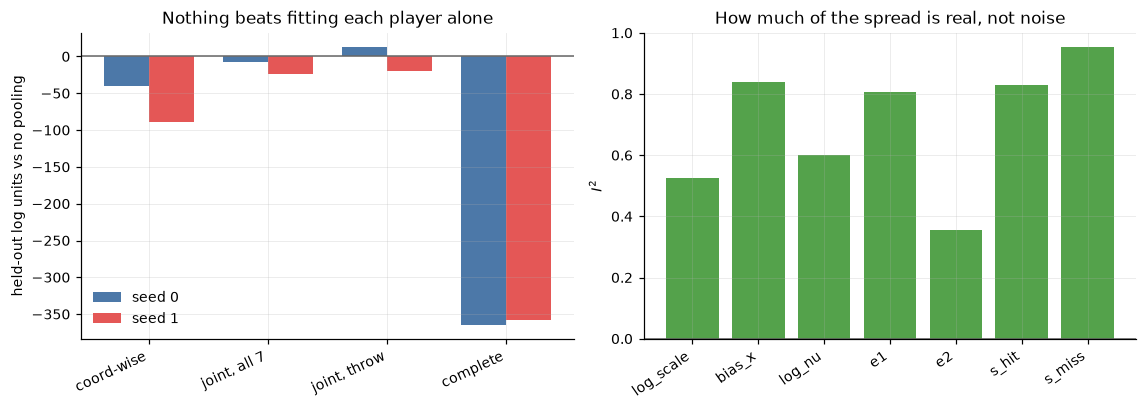

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.8))
labels = [r[0].replace('joint, ', 'joint: ') for r in rows]
x = np.arange(len(rows))
w = 0.38
ax[0].axhline(0, color='0.4', lw=1)
ax[0].bar(x - w / 2, [r[1] for r in rows], w, color='#4c78a8', label='seed 0')
ax[0].bar(x + w / 2, [r[2] for r in rows], w, color='#e45756', label='seed 1')
ax[0].set_xticks(x, ['coord-wise', 'joint, all 7', 'joint, throw', 'complete'],
                 rotation=25, ha='right')
ax[0].set(ylabel='held-out log units vs no pooling',
          title='Nothing beats fitting each player alone')
ax[0].legend()

ax[1].axhline(0, color='0.4', lw=1)
ax[1].bar(np.arange(len(PARAMS)), het.I2, color='#54a24b')
ax[1].set_xticks(np.arange(len(PARAMS)),
                 [p.replace('logit_', '').replace('_minus_2', '') for p in PARAMS],
                 rotation=35, ha='right')
ax[1].set(ylabel=r'$I^2$', ylim=(0, 1),
          title='How much of the spread is real, not noise')
fig.tight_layout()

## Conclusion

**No. Fit each player separately.** On two independent splits, every variant of
partial pooling tried -- coordinate-wise, joint over all seven parameters, joint
over the four throw parameters -- lands behind no pooling, and complete pooling
lands 360 log units behind.

**Why, in one sentence:** these players differ a lot and are measured well, and
shrinkage is for the opposite case. $I^2$ is 0.53 to 0.95 on six of seven
parameters, and two hundred to six hundred visits pin a player's core scale
tightly enough that pulling it 53% toward the population throws away more than it
buys.

**The diagnostic is worth more than the answer.** Coordinate-wise shrinkage did
not merely fail, it failed *worst on the players with the least data* -- backwards
from everything shrinkage is meant to do. The reason is that the parameters are
strongly correlated across players (core scale against elongation, $-0.745$) and
pulling each toward its own mean drags the vector off the ridge they lie on.
Doing it jointly fixes most of that. Anyone applying a hierarchical model to
correlated parameters one coordinate at a time should expect this.

**And one methodological result.** The single positive number in this notebook,
$+13.2$, came from choosing among five variants by their held-out score and did
not survive a fresh split. Held-out likelihood is not a defence against
overfitting if you use it to pick the model.

**What this licenses.** Notebooks 21, 24 and 25 all fit players independently and
report per-player numbers. This is the check that the choice was right, and it
was. It also puts a price on the alternative the rest of the project uses: the
ability bands treat a standard of play as one parameter set, and complete pooling
across seventeen professionals costs 0.067 a visit -- a tenth of the entire
Gaussian-to-Student-t gain. The bands are a useful summary, not a player.

**What is still open.** Seventeen units is few for a hierarchical model: the tests
for `darts.hierarchical` put the power to detect a moderate $\tau = 0.3$ at about
62%, and a full $7\times 7$ population covariance is 28 numbers from 12 usable
players. With a hundred players -- which the data would support at a lower visit
threshold, at the cost of noisier individual fits -- the balance could easily go
the other way, and that is the version of this experiment worth running next.